Lab Experiment 5: Linear Regression through Gradient Descent

Import Required Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

Load Dataset

In [32]:
df = pd.read_csv("D:\\Christ work\\MacLearn\\Labs\\Lab5\\student\\student-mat.csv", sep=";")
df.info()
df.head()
df.shape
df.columns
df.describe()
df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      395 non-null    str  
 1   sex         395 non-null    str  
 2   age         395 non-null    int64
 3   address     395 non-null    str  
 4   famsize     395 non-null    str  
 5   Pstatus     395 non-null    str  
 6   Medu        395 non-null    int64
 7   Fedu        395 non-null    int64
 8   Mjob        395 non-null    str  
 9   Fjob        395 non-null    str  
 10  reason      395 non-null    str  
 11  guardian    395 non-null    str  
 12  traveltime  395 non-null    int64
 13  studytime   395 non-null    int64
 14  failures    395 non-null    int64
 15  schoolsup   395 non-null    str  
 16  famsup      395 non-null    str  
 17  paid        395 non-null    str  
 18  activities  395 non-null    str  
 19  nursery     395 non-null    str  
 20  higher      395 non-null    str  
 21  inte

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Observation

The dataset was loaded successfully. It contains information about students, including demographic details, study habits, family background, and academic performance. The dataset contains both numerical and categorical attributes. Understanding the data types helps determine the preprocessing steps required before training the model. No missing values were found in the dataset, so no additional cleaning was required before preprocessing. The dataset contains several attributes describing student characteristics. The final grade (G3) will later be selected as the target variable for prediction.

Encode Categorical Variables

Since Linear Regression works only with numerical data, we need to convert all categorical columns into numerical values.

In [33]:
df = pd.get_dummies(df, drop_first=True)
df.head()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,guardian_mother,guardian_other,schoolsup_yes,famsup_yes,paid_yes,activities_yes,nursery_yes,higher_yes,internet_yes,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,True,False,True,False,False,False,True,True,False,False
1,17,1,1,1,2,0,5,3,3,1,...,False,False,False,True,False,False,False,True,True,False
2,15,1,1,1,2,3,4,3,2,2,...,True,False,True,False,True,False,True,True,True,False
3,15,4,2,1,3,0,3,2,2,1,...,True,False,False,True,True,True,True,True,True,True
4,16,3,3,1,2,0,4,3,2,1,...,False,False,False,True,True,False,True,True,False,False


Observation

I converted all categorical variables into numerical values using one-hot encoding. This made the dataset suitable for training the Linear Regression model while avoiding the dummy variable trap.

Select Input Features and Target Variable

The objective is to predict the student's final grade (G3)

In [34]:
X = df.drop("G3", axis=1)
y = df["G3"]
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (395, 41)
Target Shape   : (395,)


Observation

I selected all the available attributes except G3 as input features and used G3 as the target variable for prediction.

Split the Dataset

Split the data into 80% training and 20% testing.

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Data :", X_train.shape)
print("Testing Data  :", X_test.shape)

Training Data : (316, 41)
Testing Data  : (79, 41)


Observation

The dataset was divided into training and testing sets. The training set was used to build the model, while the testing set was reserved for evaluating its performance.

Feature Scaling

Gradient Descent performs better when all features are on a similar scale.

In [36]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Observation

I standardized the input features so that they have a mean close to 0 and a standard deviation close to 1. This helps Gradient Descent converge faster and improves training stability.

Verify the Scaled Data

In [37]:
print(X_train[:5])

[[-0.58639605  0.24643712  0.42320737 -0.62577865 -0.05685286 -0.45674383
   0.06443217 -1.19598096 -0.14439599 -0.55443033 -0.2664957  -0.36847328
  -0.46440769  0.33205033  0.62616324 -0.34722813  1.07906606  0.52853782
  -0.63105474  0.33567254 -0.30565602 -0.73073975  1.66189794 -0.40219983
  -0.23094011  0.88050037 -0.59684435 -0.26680787  1.66189794 -0.33567254
  -0.59684435  0.66552414 -0.30565602 -0.40219983 -1.23612297  1.08596056
   1.00634927  0.49901088  0.24576958  0.43869446  1.37807205]
 [-0.58639605 -0.68063585  0.42320737  0.82823645 -1.25455313 -0.45674383
   1.19557467 -0.21434464 -0.14439599 -0.55443033 -1.03908875 -0.36847328
  -0.70225668  0.64340909  0.89283114 -0.34722813  1.07906606  0.52853782
  -0.63105474  0.33567254 -0.30565602  1.36847626 -0.60172167 -0.40219983
  -0.23094011  0.88050037 -0.59684435 -0.26680787  1.66189794 -0.33567254
  -0.59684435 -1.50257511 -0.30565602 -0.40219983 -1.23612297 -0.92084375
  -0.99369079  0.49901088  0.24576958  0.43869446

Observation

The transformed values are no longer in their original units because they have been standardized. This ensures that no single feature dominates the learning process due to its larger scale.

Implement Linear Regression using Gradient Descent

In [38]:
class LinearRegressionGD:

    def __init__(self, learning_rate=0.01, iterations=1000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):

        self.m, self.n = X.shape

        # Initialize weights and bias
        self.weights = np.zeros(self.n)
        self.bias = 0

        # Store cost values
        self.cost_history = []

        # Gradient Descent
        for i in range(self.iterations):

            # Predicted values
            y_pred = np.dot(X, self.weights) + self.bias

            # Compute gradients
            dw = (1/self.m) * np.dot(X.T, (y_pred - y))
            db = (1/self.m) * np.sum(y_pred - y)

            # Update parameters
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Calculate Cost (Mean Squared Error Cost Function)
            cost = (1/(2*self.m)) * np.sum((y_pred - y)**2)
            self.cost_history.append(cost)

    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

Observation

I implemented the Linear Regression algorithm from scratch using Gradient Descent. The algorithm repeatedly updated the weights and bias to minimize the prediction error.

Train the Model

In [39]:
model = LinearRegressionGD(
    learning_rate=0.01,
    iterations=1000
)

model.fit(X_train, y_train)

Observation

The model was trained using the training dataset. During each iteration, the parameters were adjusted to reduce the cost function.

View the Final Cost

In [40]:
print("Final Cost:", model.cost_history[-1])

Final Cost: 1.4302497326261971


Observation

The final cost was much lower than the initial cost, indicating that the model successfully learned from the training data.

Plot Cost vs Number of Iterations

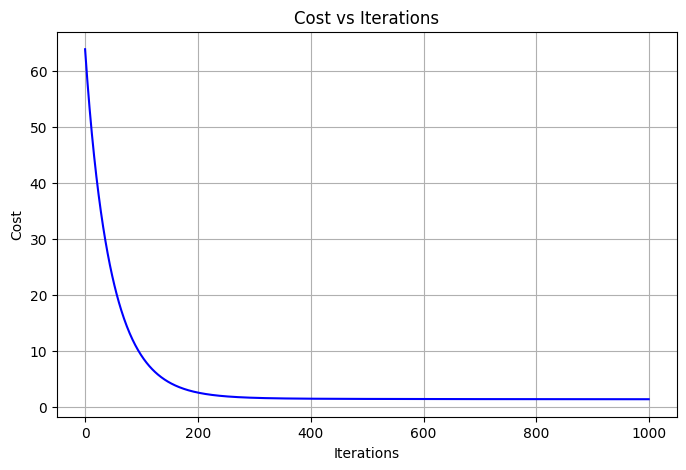

In [41]:
plt.figure(figsize=(8,5))

plt.plot(model.cost_history, color='blue')

plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")

plt.grid(True)

plt.show()

Observation

The graph showed a gradual decrease in the cost value as the number of iterations increased. This indicates that Gradient Descent converged successfully toward the minimum cost.

Make Predictions

In [42]:
y_pred = model.predict(X_test)

y_pred[:10]

array([ 6.37349571, 11.92764887,  2.34510964,  8.83212236,  8.55226523,
       11.90453388, 19.14638596,  7.31832414,  7.32720661, 11.88368026])

Observation

The trained model generated predictions for the testing dataset based on the learned relationship between the input features and the target variable.

Experiment with Different Learning Rates

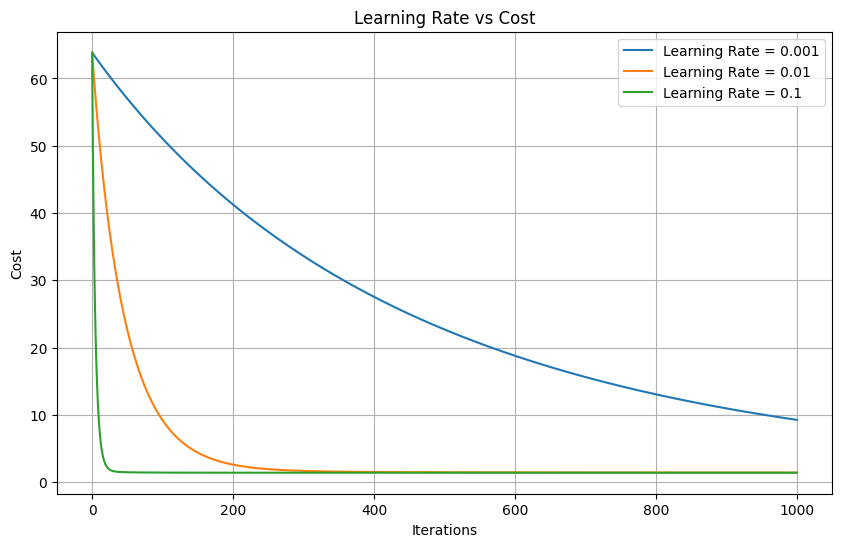

In [43]:
learning_rates = [0.001, 0.01, 0.1]

plt.figure(figsize=(10,6))

for lr in learning_rates:

    temp_model = LinearRegressionGD(
        learning_rate=lr,
        iterations=1000
    )

    temp_model.fit(X_train, y_train)

    plt.plot(temp_model.cost_history, label=f"Learning Rate = {lr}")

plt.title("Learning Rate vs Cost")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.legend()
plt.grid(True)

plt.show()

Observation

I observed that the learning rate had a significant impact on the convergence of Gradient Descent. A smaller learning rate converged slowly, whereas a larger learning rate reached the minimum cost much faster. However, if the learning rate is too high, it may overshoot the minimum and fail to converge properly.

Evaluate the Model

In [44]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 1.6700289430321869
Mean Squared Error (MSE): 5.6936391694756425
Root Mean Squared Error (RMSE): 2.386134776050096
R² Score: 0.7223298685908052


Observation

The evaluation metrics measured the prediction accuracy of the trained model. Lower values of MAE, MSE, and RMSE indicate better prediction performance, while an R² score closer to 1 indicates that the model explains a larger proportion of the variance in the target variable.

Compare Actual and Predicted Values

In [45]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": np.round(y_pred, 2)
})

comparison.head(10)

,Actual,Predicted
0,10,6.37
1,12,11.93
2,5,2.35
3,10,8.83
4,9,8.55
5,13,11.90
6,18,19.15
7,6,7.32
8,0,7.33
9,14,11.88


Observation

The predicted values were reasonably close to the actual values, showing that the model was able to learn the relationship between the input features and the final student grades.

Plot Actual vs Predicted Values

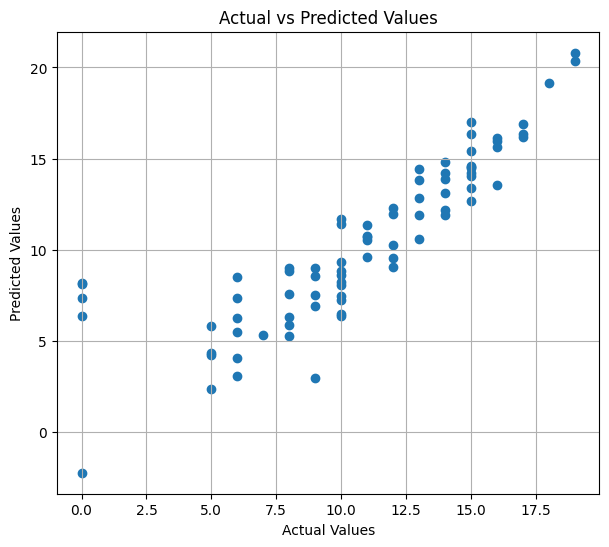

In [46]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values")

plt.grid(True)

plt.show()

Observation

The scatter plot showed that most of the predicted values were clustered near the actual values. This indicates that the model produced reasonably accurate predictions for the testing dataset.